<a href="https://colab.research.google.com/github/amakello/Kujenga/blob/main/Akello_Odundo_Kenya_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hypothesis Testing

Akello Odundo

Kenya

Assignment 3

**Formulating the Hypothesis**

I will be using a one-sided hypothesis testing, because I wish to test in one specific direction (as opposed to searching for significant differences).

Null Hypothesis: Runners training at high altitudes have the same race times as runners training at sea altitudes.

Alternate Hypothesis: Runners training at high altitudes have lower race times than runners training at sea altitudes.

**Loading the Data Set**

An Excel sheet was created using the provided data set for high altitude runners and sea altitude runners. This was then converted to "Akello Runners.csv" and uploaded to colabs for use.

In [11]:
from google.colab import files
import pandas as pd
import io

print("Akello Runners.csv")
#

Akello Runners.csv


In [13]:
display(df)

,High Altitude,Sea Altitude
0,1931.2,1958.6
1,1928.4,1961.9
2,1942.1,1949.5
3,1919.7,1965.2
4,1935.3,1953.8
5,1922.8,1962.3
6,1917.4,1947.9
7,1940.9,1956.7
8,1938.2,1970.1
9,1926.5,1959.4


**Sampling and Comparing the Data Sets**

To compare the data sets, the mean, the standard deviation and the variance were computed.

In [22]:
# The coach used 25 runners from each group

from scipy import stats

# Extract the two samples
high_altitude_times = df['High Altitude']
sea_altitude_times = df['Sea Altitude']

high_altitude_times = high_altitude_times.sample(n=25, random_state=1).tolist()
sea_altitude_times = sea_altitude_times.sample(n=25, random_state=2).tolist()
print(f"High Altitude Times: {high_altitude_times}")
print(f"Sea Altitude Times: {sea_altitude_times}")

# Now, let’s compare the averages:
from statistics import mean

print("Average High Altitude Times:", mean(high_altitude_times))
print("Average Sea Altitude Times", mean(sea_altitude_times))

High Altitude Times: [1936.7, 1918.9, 1934.2, 1919.7, 1923.1, 1933.1, 1916.8, 1929.9, 1935.3, 1942.1, 1937.4, 1917.4, 1940.9, 1932.8, 1928.4, 1941.5, 1931.2, 1921.3, 1919.3, 1927.6, 1926.5, 1938.2, 1930.4, 1924.6, 1922.8]
Sea Altitude Times: [1961.2, 1958.6, 1960.5, 1947.9, 1964.8, 1959.4, 1965.2, 1972.6, 1966.4, 1955.9, 1953.8, 1963.8, 1962.3, 1968.3, 1961.9, 1949.5, 1956.7, 1971.4, 1952.7, 1954.1, 1950.7, 1958.1, 1948.8, 1957.9, 1970.1]
Average High Altitude Times: 1929.204
Average Sea Altitude Times 1959.704


In [24]:
# Let’s also compare the standard deviations:
from statistics import stdev

std_dev_high_altitude = stdev(high_altitude_times)
std_dev_sea_altitude = stdev(sea_altitude_times)

print(f"Standard Deviation of High Altitude Times: {std_dev_high_altitude:.3f}")
print(f"Standard Deviation of Sea Altitude Times: {std_dev_sea_altitude:.3f}")

Standard Deviation of High Altitude Times: 7.945
Standard Deviation of Sea Altitude Times: 7.091


In [25]:
# Let’s further compare the variance:
from statistics import variance

variance_high_altitude = variance(high_altitude_times)
variance_sea_altitude = variance(sea_altitude_times)

print(f"Variance of High Altitude Times: {variance_high_altitude:.3f}")
print(f"Variance of Sea Altitude Times: {variance_sea_altitude:.3f}")

Variance of High Altitude Times: 63.124
Variance of Sea Altitude Times: 50.278


**Calculating the t-Statistic**

In [36]:
from scipy import stats
from scipy.stats import ttest_ind

# Extract the two samples
high_altitude_times = df['High Altitude']
sea_altitude_times = df['Sea Altitude']

# Perform the independent t-test with a one-sided alternative ('less')
t_statistic, p_value= ttest_ind(high_altitude_times, sea_altitude_times, alternative='less', equal_var=False)
print(f"T-statistic:, {t_statistic:.3f}")
print(f"P-value:, {p_value:.3f}")

# Define significance level
alpha = 0.05

# Compare p-value with alpha to make a decision
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is significant evidence that runners training at high altitudes have lower race times than runners training at sea altitudes.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant evidence that runners training at high altitudes have lower race times than runners training at sea altitudes.")

T-statistic:, -14.321
P-value:, 0.000
Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: There is significant evidence that runners training at high altitudes have lower race times than runners training at sea altitudes.



*   T-statistic: -14.321
*   P-value: 0.000

A p-value of 0 indicates extreme statistical significance, meaning the observed results are highly unlikely to be due to chance alone under the null hypothesis. It suggests the null hypothesis is almost certainly false.
Further, since the p-value of 0 is less than the significance level of -14.321, the null hypothesis can confidently be rejected.

It can be concluded that there is significant evidence that runners training at high altitudes have lower race times than runners training at sea altitudes.

**Creating the Box Plot**

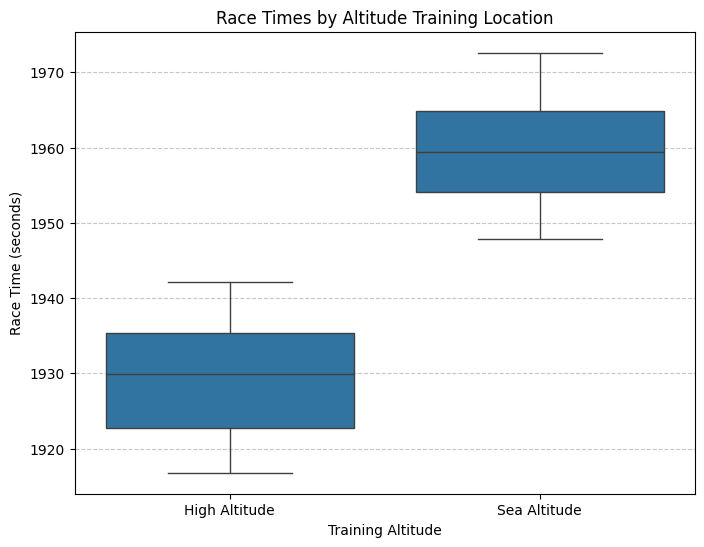

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Altitude': ['High Altitude'] * len(high_altitude_times) + ['Sea Altitude'] * len(sea_altitude_times),
    'Race Time': pd.concat([high_altitude_times, sea_altitude_times])
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Altitude', y='Race Time', data=plot_df)
plt.title('Race Times by Altitude Training Location')
plt.xlabel('Training Altitude')
plt.ylabel('Race Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Creating the Histogram**

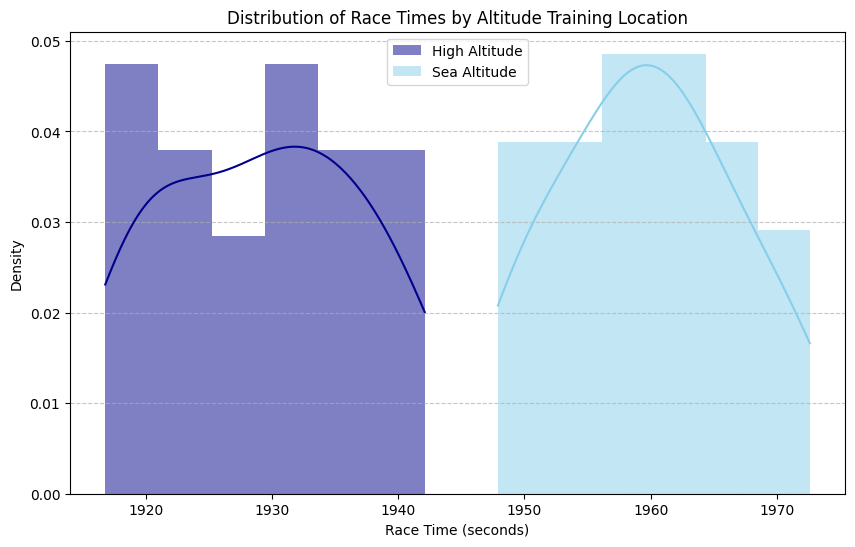

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(high_altitude_times, color='darkblue', label='High Altitude', kde=True, stat='density', linewidth=0)
sns.histplot(sea_altitude_times, color='skyblue', label='Sea Altitude', kde=True, stat='density', linewidth=0)

plt.title('Distribution of Race Times by Altitude Training Location')
plt.xlabel('Race Time (seconds)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From comparing the t-statistic and the p-value, it has been show that runners training at high altitudes have lower race times than runners training at sea altitudes.

By looking at both the box plot and the histogram, there is further evidence that runners training at high altitudes have lower race times than runners training at sea altitudes.